# MLP Matrix Learning 2
This notebook trains a multi-layer perception network using triplet margin loss to understand similar commits, using embeddings of commits as training data and input. This version uses more training data compared to the previous version.

# Obtain commit hashes and embedding

In [1]:
import os
import glob
import json
import numpy as np

LEARNING_RATE = 0.000001
EMBEDDING_PATH = 'data/initial_embedding/embeddings_accumulo.npy'
COMMIT_HASHES_PATH = 'data/commit_hashes/commit_hashes_accumulo.json'
MODEL_SAVE_PATH = 'triplet_intraproject.pth'

COMMIT_HASHES_PATH

'data/commit_hashes/commit_hashes_accumulo.json'

### Concatenate lists of commit hashes

In [2]:
with open(COMMIT_HASHES_PATH, 'r') as file:
    commit_hashes = json.load(file)
        

In [3]:
len(commit_hashes)

10741

### Concatenate list of embeddings

In [4]:
import numpy as np

# embedding_folder = os.path.join(os.getcwd(), "data/initial_embedding")
# embedding_paths = glob.glob(os.path.join(embedding_folder, '*.npy'))

# embeddings = np.load(embedding_paths[0])

# for path in embedding_paths[1:]:
#     embedding = np.load(path)
#     embeddings = np.vstack((embeddings, embedding))

In [5]:
embeddings = np.load(EMBEDDING_PATH)

In [6]:
embeddings.shape

(10741, 768)

## Create training dataset

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn


class TripleCommitDataset(Dataset):
    def __init__(self, anchors, positive, negative):
        self.anchors = torch.FloatTensor(anchors)
        self.positive = torch.FloatTensor(positive)
        self.negative = torch.FloatTensor(negative)

    def __len__(self):
        return len(self.anchors)

    def __getitem__(self, idx):
        anchor = self.anchors[idx]
        pos = self.positive[idx]
        neg = self.negative[idx]
        return anchor, pos, neg
    

In [8]:
import json
triplets_dataset_train_path = 'data/triplets_accumulo_train.json'
with open(triplets_dataset_train_path, 'r') as file:
    triplets_train_data = json.load(file)

anchors_train = [entry['anchor'] for entry in triplets_train_data]
positives_train = [entry['positive'] for entry in triplets_train_data]
negatives_train = [entry['negative'] for entry in triplets_train_data]

anchors_train_embeddings = [embeddings[commit_hashes.index(anchor)] 
                      for anchor in anchors_train]

positives_train_embeddings = [embeddings[commit_hashes.index(pos)] 
                        for pos in positives_train]

negatives_train_embeddings = [embeddings[commit_hashes.index(neg)] 
                        for neg in negatives_train]

print(f"{len(anchors_train_embeddings)} {len(positives_train_embeddings)} {len(negatives_train_embeddings)}" )



6 6 6


In [9]:
train_dataset = TripleCommitDataset(anchors_train_embeddings, positives_train_embeddings, negatives_train_embeddings)
train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True, drop_last=True)

/var/folders/hq/mr_d9f8x11dfzc_f03z9xzbw0000gn/T/ipykernel_34623/3759271055.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  self.anchors = torch.FloatTensor(anchors)


In [10]:
import json
triplets_dataset_test_path = 'data/triplets_accumulo_test.json'
with open(triplets_dataset_test_path, 'r') as file:
    triplets_test_data = json.load(file)

anchors_test = [entry['anchor'] for entry in triplets_test_data]
positives_test = [entry['positive'] for entry in triplets_test_data]
negatives_test = [entry['negative'] for entry in triplets_test_data]

anchors_test_embeddings = [embeddings[commit_hashes.index(anchor)] 
                      for anchor in anchors_test]

positives_test_embeddings = [embeddings[commit_hashes.index(pos)] 
                        for pos in positives_test]

negatives_test_embeddings = [embeddings[commit_hashes.index(neg)] 
                        for neg in negatives_test]

print(f"{len(anchors_test_embeddings)} {len(positives_test_embeddings)} {len(negatives_test_embeddings)}" )



2 2 2


In [11]:
test_dataset = TripleCommitDataset(anchors_test_embeddings, positives_test_embeddings, negatives_test_embeddings)
test_dataloader = DataLoader(test_dataset, batch_size=2, shuffle=True, drop_last=True)

## Define MLP

In [12]:
class MLPEmbedding(nn.Module):
    def __init__(self, input_dim=768, output_dim=64):
        super().__init__()
        self.net = nn.Sequential(
                    nn.Linear(768, 512),
                    nn.BatchNorm1d(512),
                    nn.Tanh(),
                    nn.Linear(512, 256),
                    nn.BatchNorm1d(256),
                    nn.Tanh(),
                    nn.Linear(256, 64)
                )
    def forward(self, x):
        return self.net(x)
    
model = MLPEmbedding(768, 64)

## Setup Optimiser and Loss

In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
triplet_loss = nn.TripletMarginLoss(margin=0.5)


## Train the MLP

### Implement Early Stopping

In [14]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)

In [15]:
import matplotlib.pyplot as plt

epochs = 100
train_losses = []
val_losses = []

# Early Stopping Parameters
patience = 10 # How many epochs to wait for improvement before stopping
min_delta = 0.001 # Minimum change in the monitored quantity to qualify as an improvement
best_val_loss = float('inf') # Initialize with a very high value
epochs_no_improve = 0 # Counter for epochs without improvement
early_stop = False # Flag to control early stopping

for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0
    for anchor, positive, negative in train_dataloader:
        optimizer.zero_grad()
        

        #Normalize the output
        anchor_out = nn.functional.normalize(model(anchor), p=2, dim=1)
        positive_out = nn.functional.normalize(model(positive), p=2, dim=1)
        negative_out = nn.functional.normalize(model(negative), p=2, dim=1)
        
        loss_value = triplet_loss(anchor_out, positive_out, negative_out)

        loss_value.backward()
        optimizer.step()
        
        total_train_loss += loss_value.item()

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    # --- Validation Phase ---
    model.eval() # Set model to evaluation mode
    total_val_loss = 0.0
    with torch.no_grad(): # Disable gradient calculations for validation
        for anchor, positive, negative in test_dataloader:
            anchor_out = nn.functional.normalize(model(anchor), p=2, dim=1)
            positive_out = nn.functional.normalize(model(positive), p=2, dim=1)
            negative_out = nn.functional.normalize(model(negative), p=2, dim=1)

            loss_value = triplet_loss(anchor_out, positive_out, negative_out)
            total_val_loss += loss_value.item()

    avg_val_loss = total_val_loss / len(test_dataloader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # --- Early Stopping Logic ---
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Save the best model state
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Validation loss improved. Saving model to {MODEL_SAVE_PATH}")
    else:
        epochs_no_improve += 1
        print(f"Validation loss did not improve for {epochs_no_improve} epochs.")
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss for {patience} consecutive epochs.")
            early_stop = True
            break # Exit the training loop

    if early_stop:
        break # Exit the outer epoch loop
        
print("Training finished.")

Epoch 1/100, Train Loss: 0.7848, Val Loss: 0.6545
Validation loss improved. Saving model to triplet_intraproject.pth
Epoch 2/100, Train Loss: 0.7511, Val Loss: 0.7040
Validation loss did not improve for 1 epochs.
Epoch 3/100, Train Loss: 0.4388, Val Loss: 0.6779
Validation loss did not improve for 2 epochs.
Epoch 4/100, Train Loss: 0.8838, Val Loss: 0.6679
Validation loss did not improve for 3 epochs.
Epoch 5/100, Train Loss: 0.5813, Val Loss: 0.6466
Validation loss improved. Saving model to triplet_intraproject.pth
Epoch 6/100, Train Loss: 0.7102, Val Loss: 0.6872
Validation loss did not improve for 1 epochs.
Epoch 7/100, Train Loss: 0.4046, Val Loss: 0.6214
Validation loss improved. Saving model to triplet_intraproject.pth
Epoch 8/100, Train Loss: 0.7202, Val Loss: 0.6290
Validation loss did not improve for 1 epochs.
Epoch 9/100, Train Loss: 0.8078, Val Loss: 0.6247
Validation loss did not improve for 2 epochs.
Epoch 10/100, Train Loss: 0.4888, Val Loss: 0.6413
Validation loss did no

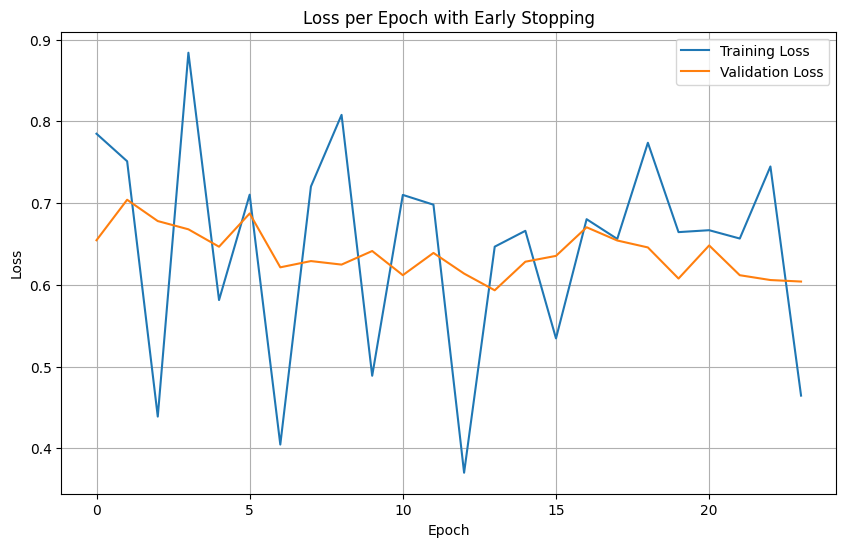

In [16]:
# Plotting the losses
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss per Epoch with Early Stopping')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()